# EDA Election Task

## Dataset Loading & Basic Inspection

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
national_df = pd.read_csv('indian-national-level-election.csv')
state_df = pd.read_csv('indian-state-level-election.csv')
print("National Dataset Shape:", national_df.shape)
print("State Dataset Shape:", state_df.shape)
national_df.head()

National Dataset Shape: (73081, 11)
State Dataset Shape: (327294, 11)


,st_name,year,pc_no,pc_name,pc_type,cand_name,cand_sex,partyname,partyabbre,totvotpoll,electors
0,Andaman & Nicobar Islands,1977,1,Andaman & Nicobar Islands,GEN,K.R. Ganesh,M,Independents,IND,25168,85308
1,Andaman & Nicobar Islands,1977,1,Andaman & Nicobar Islands,GEN,Manoranjan Bhakta,M,Indian National Congress,INC,35400,85308
2,Andaman & Nicobar Islands,1980,1,Andaman & Nicobar Islands,GEN,Ramesh Mazumdar,M,Independents,IND,109,96084
3,Andaman & Nicobar Islands,1980,1,Andaman & Nicobar Islands,GEN,Alagiri Swamy,M,Independents,IND,125,96084
4,Andaman & Nicobar Islands,1980,1,Andaman & Nicobar Islands,GEN,Kannu Chemy,M,Independents,IND,405,96084


In [3]:
#Data Inspection
state_df.head()
state_df.tail()

,st_name,year,ac_no,ac_name,ac_type,cand_name,cand_sex,partyname,partyabbre,totvotpoll,electors
327289,West Bengal,2011.0,294,Murarai,GEN,Ajrail Md,M,IND,IND,2471.0,189320
327290,West Bengal,2011.0,294,Murarai,GEN,Shiblal Sardar,M,BSP,BSP,3074.0,189320
327291,West Bengal,2011.0,294,Murarai,GEN,Sudhiranjan Das Goswami,M,BJP,BJP,4961.0,189320
327292,West Bengal,2011.0,294,Murarai,GEN,Elahi Kamre Dr,M,CPM,CPM,73414.0,189320
327293,West Bengal,2011.0,294,Murarai,GEN,Nure Alam Chowdhury,M,AITC,AITC,77817.0,189320


In [9]:
national_df.info()
print("\n\n")
state_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73081 entries, 0 to 73080
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   st_name     73081 non-null  object
 1   year        73081 non-null  int64 
 2   pc_no       73081 non-null  int64 
 3   pc_name     73081 non-null  object
 4   pc_type     65011 non-null  object
 5   cand_name   73081 non-null  object
 6   cand_sex    72539 non-null  object
 7   partyname   73081 non-null  object
 8   partyabbre  73081 non-null  object
 9   totvotpoll  73081 non-null  int64 
 10  electors    73081 non-null  int64 
dtypes: int64(4), object(7)
memory usage: 6.1+ MB


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 327294 entries, 0 to 327293
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   st_name     327294 non-null  object 
 1   year        327294 non-null  float64
 2   ac_no       327294 non-null  int64 

## Data Cleaning

In [4]:
# Missing values
print(national_df.isnull().sum().sort_values(ascending=True))
print(state_df.isnull().sum().sort_values(ascending=True))

# Dropping unnecessary columns
national_df.drop('partyabbre',axis=1,inplace=True)
state_df.drop('partyabbre',axis=1,inplace=True)

# Drop duplicates
national_df = national_df.drop_duplicates()
state_df = state_df.drop_duplicates()

# Filling missing values accordingly
national_df['cand_sex']=national_df['cand_sex'].fillna(national_df['cand_sex'].mode()[0])
national_df['pc_type'] = national_df['pc_type'].fillna(national_df['pc_type'].mode()[0])

state_df['cand_sex']=state_df['cand_sex'].fillna(state_df['cand_sex'].mode()[0])
state_df['totvotpoll'] = state_df['totvotpoll'].fillna(state_df['totvotpoll'].median())
state_df['ac_name'] = state_df['ac_name'].fillna(state_df['ac_name'].mode()[0])

# Fixing Data Types
state_df['year']=state_df['year'].astype(np.int64)
state_df['totvotpoll']=state_df['totvotpoll'].astype(np.int64)

st_name          0
year             0
pc_no            0
pc_name          0
cand_name        0
partyname        0
totvotpoll       0
partyabbre       0
electors         0
cand_sex       542
pc_type       8070
dtype: int64
st_name           0
year              0
ac_no             0
ac_type           0
partyname         0
cand_name         0
electors          0
totvotpoll        7
partyabbre     2706
cand_sex       5302
ac_name       16083
dtype: int64


In [5]:
national_df['pc_type'].sort_values().unique()
national_df['pc_type'] = national_df['pc_type'].str.replace('SC ', 'SC', regex=False) #standardizing the value "SC " with "SC"

In [6]:
print(national_df.isnull().sum().sort_values(ascending=True))
print("\n")
print(state_df.isnull().sum().sort_values(ascending=True))

st_name       0
year          0
pc_no         0
pc_name       0
pc_type       0
cand_name     0
cand_sex      0
partyname     0
totvotpoll    0
electors      0
dtype: int64


st_name       0
year          0
ac_no         0
ac_name       0
ac_type       0
cand_name     0
cand_sex      0
partyname     0
totvotpoll    0
electors      0
dtype: int64


## Univariate Analysis

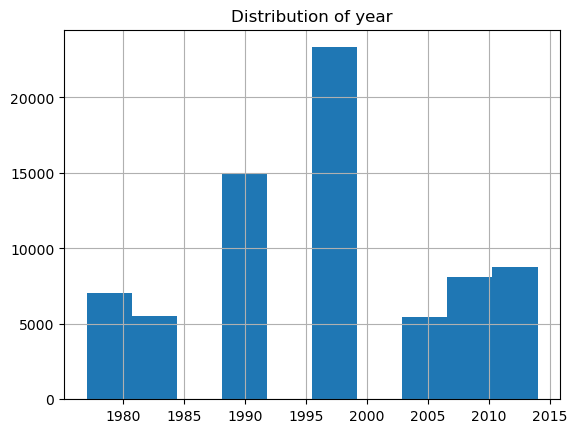

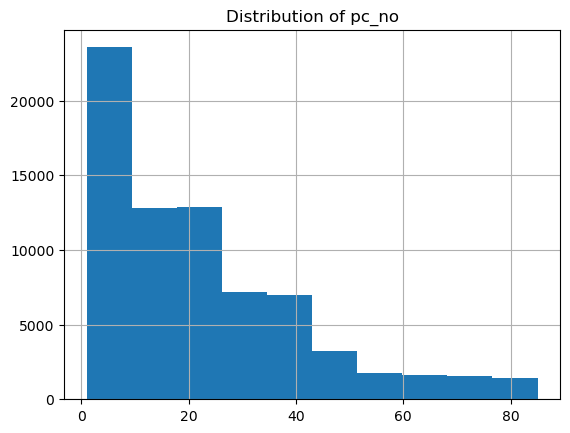

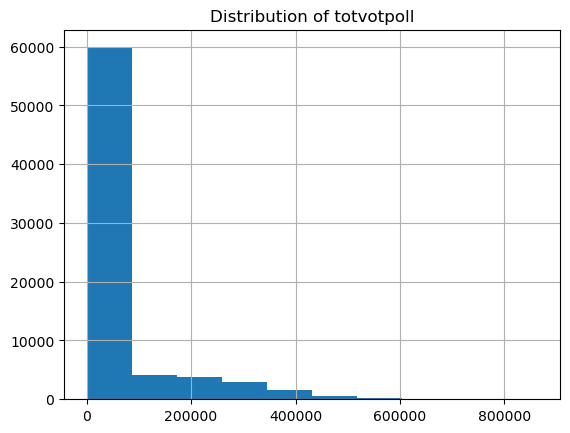

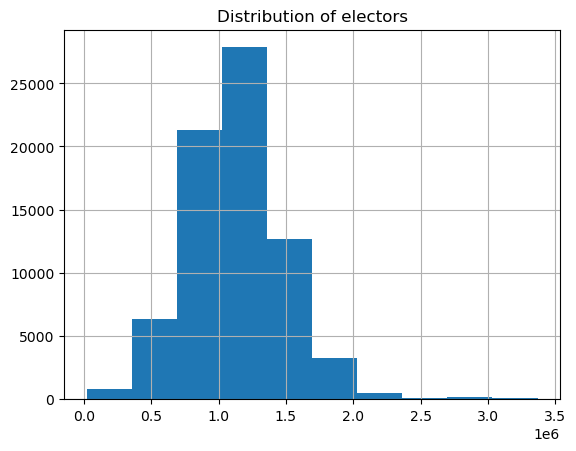

In [7]:
# Votes Distribution
num_cols = national_df.select_dtypes(include=np.number).columns
for col in num_cols:
    plt.figure()
    national_df[col].hist()
    plt.title(f'Distribution of {col}')
    plt.show()

## Bivariate Analysis

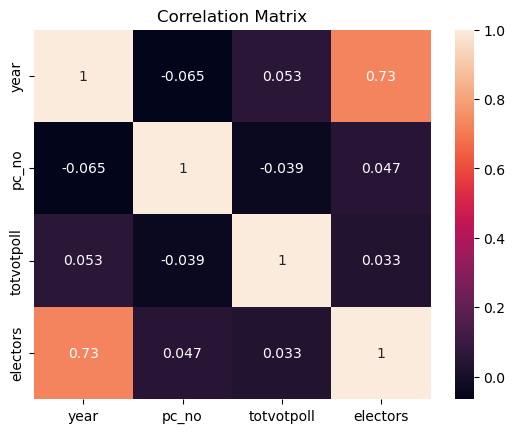

In [8]:
# Correlation heatmap
plt.figure()
sns.heatmap(national_df.select_dtypes(include=np.number).corr(), annot=True)
plt.title('Correlation Matrix')
plt.show()

## Multivariate Analysis

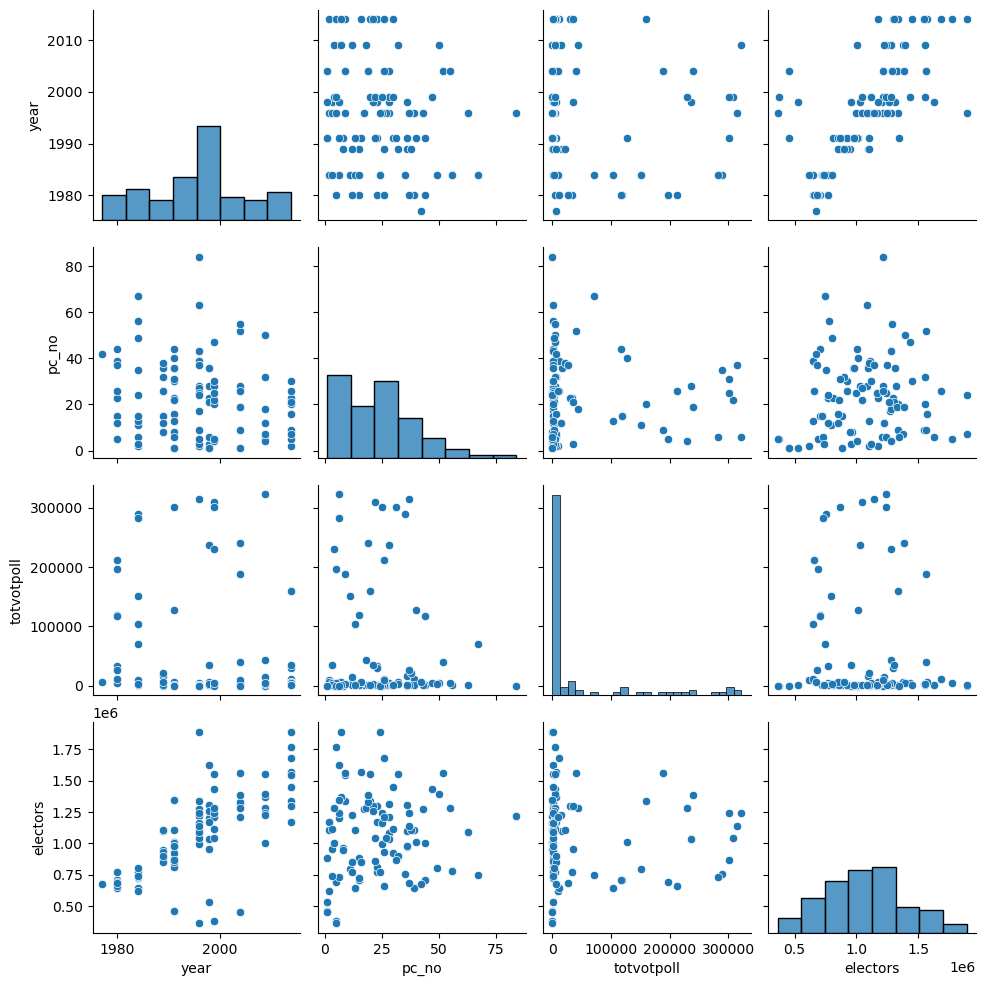

In [9]:
# Pairplot
sns.pairplot(national_df.select_dtypes(include=np.number).sample(100))
plt.show()

## Key Visualizations

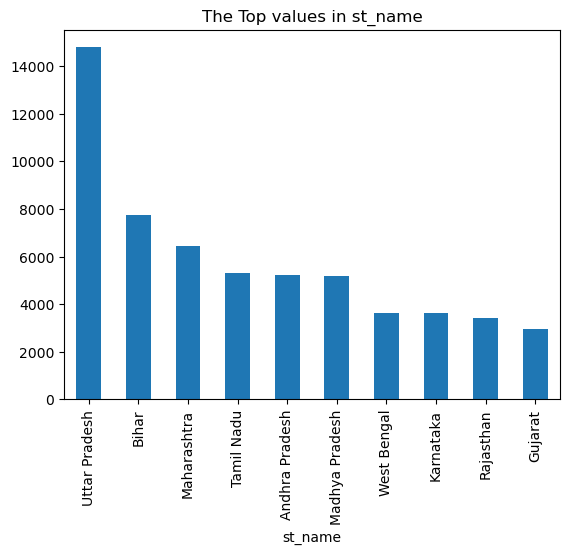

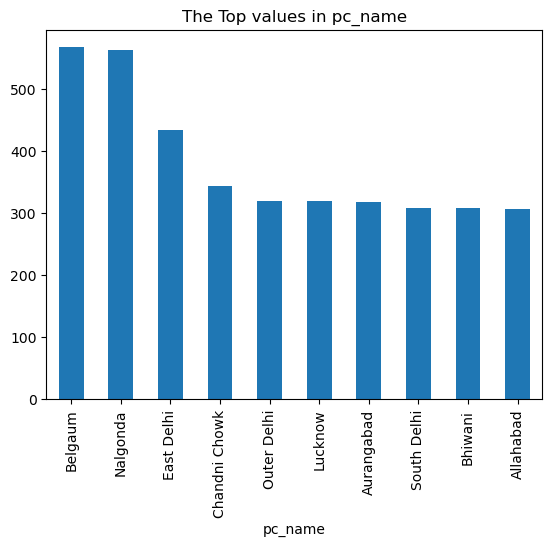

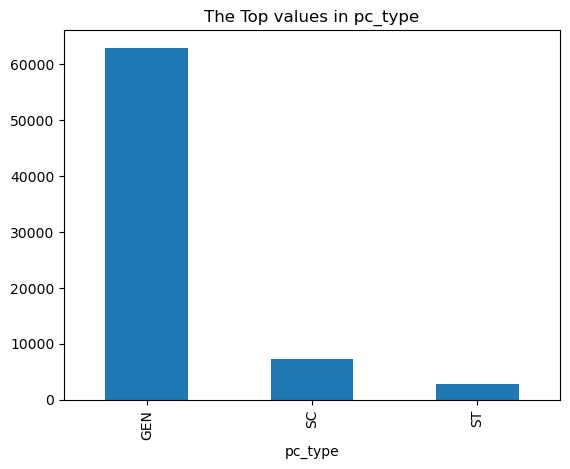

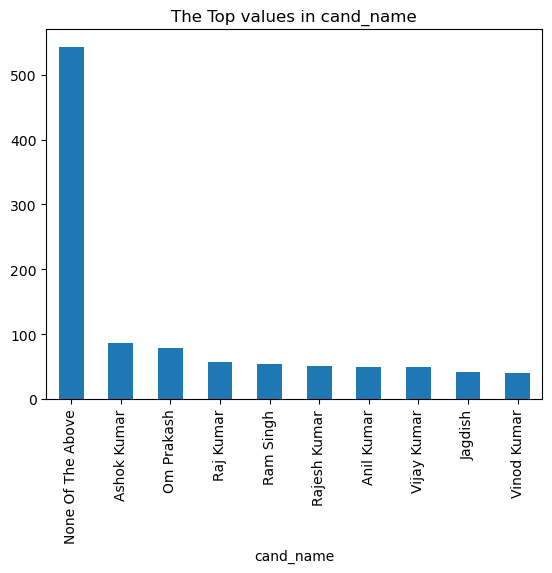

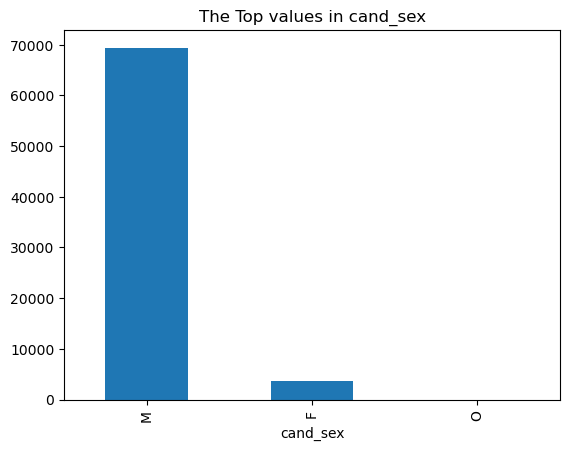

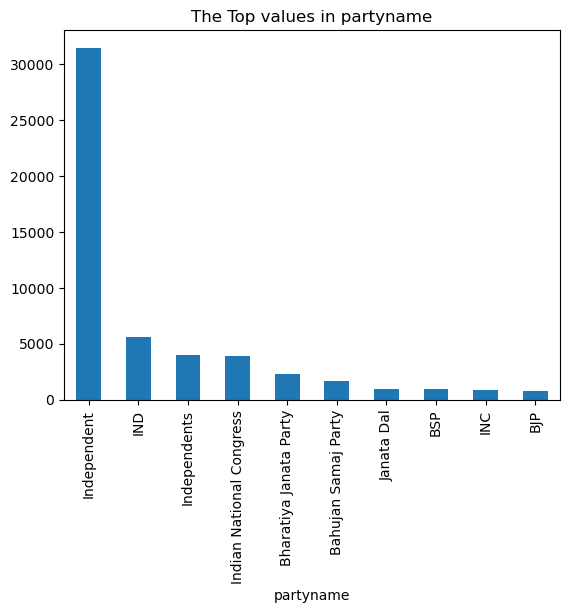

In [10]:
# Top categories if categorical column exists
cat_cols = national_df.select_dtypes(include='object').columns
for col in cat_cols[::]:
    plt.figure()
    national_df[col].value_counts().head(10).plot(kind='bar')
    plt.title(f'The Top values in {col}')
    plt.show()

## Key Insights & Observations

1. Identified distributions and skewness in numerical variables
2. Observed correlations between key election metrics
3. Top categories highlight dominant parties/regions
4. Clean dataset ensures accurate analysis

## Conclusion

### This EDA provides insights into election trends, relationships between variables, and dominant patterns across datasets.